<a href="https://colab.research.google.com/github/gustavojacques/inform-tica-/blob/main/cerveja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dongeorge/beer-consumption-sao-paulo")

print("Path to dataset files:", path)

100%|██████████| 5.24k/5.24k [00:00<00:00, 7.93MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dongeorge/beer-consumption-sao-paulo/versions/2


In [6]:
import pandas as pd
import os

In [7]:
# List the contents of the downloaded directory to find the CSV file
print("Files in dataset directory:", os.listdir(path))

Files in dataset directory: ['Consumo_cerveja.csv']


In [8]:
# Based on the dataset description and common Kaggle practices, the CSV file is likely 'Consumo_cerveja.csv'.
# We'll construct the full path to the CSV file.
csv_file_name = 'Consumo_cerveja.csv'
df_path = os.path.join(path, csv_file_name)

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(df_path)

# Display the first 5 rows of the DataFrame to verify the load
display(df.head())

,Data,Temperatura Media (C),Temperatura Minima (C),Temperatura Maxima (C),Precipitacao (mm),Final de Semana,Consumo de cerveja (litros)
0,2015-01-01,"27,3","23,9","32,5",0,0.0,25.461
1,2015-01-02,"27,02","24,5","33,5",0,0.0,28.972
2,2015-01-03,"24,82","22,4","29,9",0,1.0,30.814
3,2015-01-04,"23,98","21,5","28,6","1,2",1.0,29.799
4,2015-01-05,"23,82",21,"28,3",0,0.0,28.900


In [9]:
df_selected = df[['Temperatura Media (C)', 'Consumo de cerveja (litros)']]
display(df_selected.head())

,Temperatura Media (C),Consumo de cerveja (litros)
0,"27,3",25.461
1,"27,02",28.972
2,"24,82",30.814
3,"23,98",29.799
4,"23,82",28.900


### Data Cleaning and Preprocessing for Linear Regression

Before we can perform linear regression, we need to ensure our data is in a suitable format. Specifically, the 'Temperatura Media (C)' column uses commas (`,`) as decimal separators, which needs to be converted to periods (`.`) so that pandas can recognize them as numeric. We also need to handle any missing values (NaNs) in the selected columns.

In [12]:
# Replace comma with dot for decimal separation in 'Temperatura Media (C)'
df_cleaned = df_selected.copy()
df_cleaned['Temperatura Media (C)'] = df_cleaned['Temperatura Media (C)'].astype(str).str.replace(',', '.', regex=False)

# Convert both columns to numeric, coercing errors to NaN
df_cleaned['Temperatura Media (C)'] = pd.to_numeric(df_cleaned['Temperatura Media (C)'], errors='coerce')
df_cleaned['Consumo de cerveja (litros)'] = pd.to_numeric(df_cleaned['Consumo de cerveja (litros)'], errors='coerce')

# Drop rows where either of the selected columns has NaN values
df_cleaned = df_cleaned.dropna()

# Display the info and head of the cleaned DataFrame to verify
print("DataFrame Info after cleaning:")
df_cleaned.info()
print("\nHead of DataFrame after cleaning:")
display(df_cleaned.head())

DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Temperatura Media (C)        365 non-null    float64
 1   Consumo de cerveja (litros)  365 non-null    float64
dtypes: float64(2)
memory usage: 8.6 KB

Head of DataFrame after cleaning:


,Temperatura Media (C),Consumo de cerveja (litros)
0,27.30,25.461
1,27.02,28.972
2,24.82,30.814
3,23.98,29.799
4,23.82,28.900


### Performing Linear Regression

Now that the data is clean, we can proceed with building a linear regression model. We will use 'Temperatura Media (C)' as our independent variable (X) and 'Consumo de cerveja (litros)' as our dependent variable (y). The data will be split into training and testing sets to evaluate the model's performance.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df_cleaned[['Temperatura Media (C)']]
y = df_cleaned['Consumo de cerveja (litros)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Coefficients: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Coefficients: 0.77
Intercept: 8.94
Mean Squared Error (MSE): 16.12
R-squared (R2): 0.27


### Visualizing the Linear Regression Results

To better understand the relationship and the model's fit, let's visualize the actual vs. predicted values and the regression line.

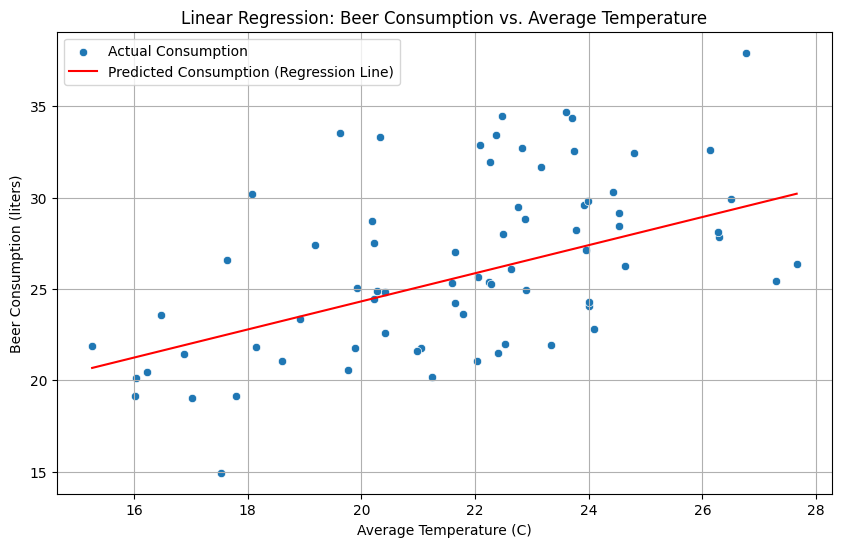

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Temperatura Media (C)'], y=y_test, label='Actual Consumption')
sns.lineplot(x=X_test['Temperatura Media (C)'], y=y_pred, color='red', label='Predicted Consumption (Regression Line)')
plt.title('Linear Regression: Beer Consumption vs. Average Temperature')
plt.xlabel('Average Temperature (C)')
plt.ylabel('Beer Consumption (liters)')
plt.legend()
plt.grid(True)
plt.show()